In [104]:
from pathlib import Path
from pymupdf import Document
from PIL import Image
import io
import numpy as np
home = Path.home()

file_name = 'example_2'
pdf_path = home / f"projects/Markush/segment_example/{file_name}_page.pdf"
doc = Document(str(pdf_path))
img_array_list = []
for i in range(doc.page_count):
    page = doc.load_page(i)
    pix = page.get_pixmap(dpi=600, alpha=False)
    img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n).copy()
    img_array_list.append(img_array)
print(doc.page_count)

1


# PaddleOCR

In [40]:
from paddleocr import PaddleOCR
ocr = PaddleOCR(text_recognition_model_name='en_PP-OCRv5_mobile_rec', 
                device='gpu')

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_m

In [41]:
ocr_result = ocr.predict(img_array_list)

In [42]:
len(ocr_result)

1

In [ ]:
import pandas as pd

for res in ocr_result:
    res_df = pd.DataFrame(columns=['text', 'x_min', 'y_min', 'x_max', 'y_max'])
    res_df.loc[:,'text'] = res.json['res']['rec_texts']
    res_df.loc[:, ['x_min', 'y_min', 'x_max', 'y_max']] = res.json['res']['rec_boxes']
    res.img['ocr_res_img'].show()

In [44]:
res_df[res_df.text.str.contains("synthesis", case=False, na=False)]

,text,x_min,y_min,x_max,y_max
55,"Example 1A. Synthesis of 6-(3-methoxybenzyl)-2,",327,1529,1358,1591


# PPStructureV3

In [20]:
from paddleocr import PPStructureV3

pipeline = PPStructureV3(device='gpu')

Creating model: ('PP-DocBlockLayout', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/PP-DocBlockLayout`.
Creating model: ('PP-DocLayout_plus-L', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/PP-DocLayout_plus-L`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/official_models/PP-OCRv5_server_rec`.
Creating model: ('PP-LCNet_x1_0_table_cls', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/zqlyu2/.paddlex/off

In [105]:
output = pipeline.predict(img_array_list, use_seal_recognition=False)

Resized image size (6600x5100) exceeds max_side_limit of 4000. Resizing to fit within limit.


In [56]:
import re

def extract_example(text: str) -> str | None:
    """
    Return the 'X' from lines like
      "Example 1a: synthesis of X"
    or
      "synthesis of X"
    (i.e. the Example… prefix is now optional).
    """
    pattern = re.compile(r"""
        (?im)                            # ignore case, multiline
        ^\s*                             # start of line, skip leading whitespace
        (?:                              # OPTIONAL Example… prefix:
           Example                       #   literal “Example”
           (?:\s+\d+\s*[A-Za-z]?)?       #   optional “ 1” or “ 1a” etc.
           \s*(?:[:\-\.\r\n])\s*         #   punctuation or newline + spaces
        )?                               # end optional group
        (?:synthesis|preparation)\s+of\s+  # keywords + “ of ”
        (.+)                             # capture everything else on the line
        $                                # end of line
    """, re.VERBOSE)

    m = pattern.search(text or "")
    return m.group(1).strip() if m else None

In [106]:
import pandas as pd 

save_path = home / f'projects/Markush/segment_example/example_images/{file_name}'
Path.mkdir(save_path, exist_ok=True, parents=True)
save_counter = 0
for i, res in enumerate(output):
    layout_df = pd.DataFrame(res.json['res']["layout_det_res"]['boxes'])

    ocr_df = pd.DataFrame(columns=['text', 'x_min', 'y_min', 'x_max', 'y_max'])
    ocr_df.loc[:,'text'] = res.json['res']["overall_ocr_res"]['rec_texts']
    ocr_df.loc[:, ['x_min', 'y_min', 'x_max', 'y_max']] = res.json['res']["overall_ocr_res"]['rec_boxes']
    # display(ocr_df)
    # display(layout_df)

    ocr_df["example"] = (ocr_df["text"].fillna("").apply(extract_example))
    # ocr_df[ocr_df["example"].notna()]

    layout_df['contain_example'] = None
    for index, row in layout_df.iterrows():
        for _, example_row in ocr_df[ocr_df["example"].notna()].iterrows():
            if (row.coordinate[0] <= example_row.x_min <= row.coordinate[2] and
                row.coordinate[1] <= example_row.y_min <= row.coordinate[3]):
                layout_df.at[index, 'contain_example'] = example_row['example']
                break
    # layout_df[layout_df['contain_example'].notna()]
    crop_boxes = layout_df[layout_df['contain_example'].notna()]['coordinate'].to_list()
    for crop_box in crop_boxes:
        x_min = int(crop_box[0]-5)
        y_min = int(crop_box[1]-5)
        x_max = int(crop_box[2]+5)
        y_max = int(crop_box[3]+5)
        img_ndarray = img_array_list[i]
        Image.fromarray(img_ndarray).crop((x_min, y_min, x_max, y_max)).save(home / 'projects/Markush/segment_example/example_images/' / f'{file_name}' / f'{save_counter}.png')
        save_counter += 1


In [107]:
layout_df

,cls_id,label,score,coordinate,contain_example
0,2,text,0.972860,"[2553.6201171875, 686.3306884765625, 4382.9482...",None
1,2,text,0.964264,"[621.4588012695312, 1437.197509765625, 2449.93...",None
2,1,image,0.963323,"[638.7168579101562, 3215.28271484375, 2421.207...",None
3,2,text,0.962906,"[2475.67236328125, 5181.5283203125, 4386.07373...",None
4,2,text,0.960354,"[2500.1005859375, 1434.498046875, 4383.4331054...",None
5,2,text,0.943328,"[2481.791015625, 2020.8333740234375, 4384.9384...",None
6,2,text,0.928159,"[2473.51953125, 4180.47802734375, 4387.1152343...",None
7,1,image,0.926381,"[1379.2265625, 695.8336181640625, 2437.7885742...",None
8,2,text,0.912348,"[2475.8115234375, 3183.73388671875, 4384.64355...",None
9,12,header,0.881491,"[2127.99267578125, 450.67559814453125, 2885.54...",None


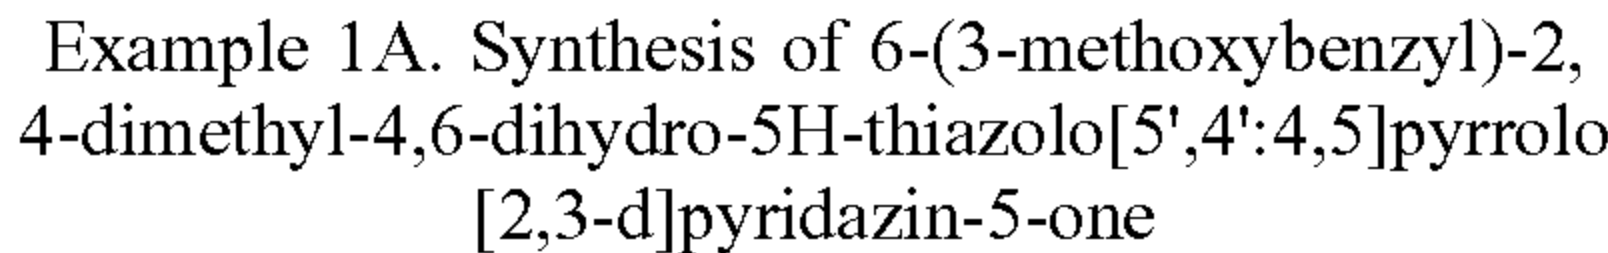

paddleocr:
Example 1A. Synthesis of 6-(3-methoxybenzyl)4-dimethy1-4,6-dihydro-5H-thiazolo[5,4':4,5]pyr[2,3-d]pyridazin-5-one
tersseract:
Example 1A. Synthesis of 6-(3-methoxybenzyl)-2,
4-dimethyl-4,6-dihydro-5H-thiazolo[5',4':4,5 ]pyrrolo
[2,3-d|pyridazin-5-one



In [108]:
import pytesseract

crop_boxes = layout_df[layout_df['contain_example'].notna()]['coordinate'].to_list()
for crop_box in crop_boxes:
    x_min = int(crop_box[0]-5)
    y_min = int(crop_box[1]-5)
    x_max = int(crop_box[2]+5)
    y_max = int(crop_box[3]+5)
    Image.fromarray(img_array_list[0]).crop(tuple(crop_box)).show()

    print("paddleocr:")
    result = ocr.predict(img_array_list[0][y_min:y_max, x_min:x_max])
    for res in result:
        print(''.join(res.json['res']['rec_texts']))
    print("tersseract:")
    print(pytesseract.image_to_string(Image.fromarray(img_array_list[0][y_min:y_max, x_min:x_max])))


# Pytesseract

In [222]:
import pytesseract

data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DATAFRAME)
data

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
0,1,1,0,0,0,0,0,0,1275,1650,-1.000000,NaN
1,2,1,1,0,0,0,534,117,188,21,-1.000000,NaN
2,3,1,1,1,0,0,534,117,188,21,-1.000000,NaN
3,4,1,1,1,1,0,534,117,188,21,-1.000000,NaN
4,5,1,1,1,1,1,534,117,31,18,96.518768,US
...,...,...,...,...,...,...,...,...,...,...,...,...
924,5,1,25,1,2,4,786,1552,28,9,96.441307,was
925,5,1,25,1,2,5,822,1548,57,17,96.441307,purified
926,5,1,25,1,2,6,887,1548,17,17,90.363060,by
927,5,1,25,1,2,7,912,1548,55,13,90.363060,column


In [226]:
data[data.text.str.contains('pyrrolo', case=False, na=False)]

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
173,5,1,7,1,1,1,187,706,397,17,5.312958,"4-dimethyl-4,6-dihydro-SH-thiazolo[5',4':4,5]p..."
394,5,1,19,2,1,4,778,363,318,17,53.288567,"2-methyl-4H-pyrrolo[2,3-d]thiazole-5-car-"
463,5,1,21,2,1,4,778,508,318,18,61.653267,"2,4-dimethyl-4H-pyrrolo[2,3-d]thiazole-5-"
471,5,1,21,2,2,7,920,529,176,18,86.396851,"2-methyl-4H-pyrrolo[2,"
594,5,1,21,3,1,4,787,799,308,18,70.717850,"6-formyl-2,4-dimethyl-4H-pyrrolo[2,3-d]"
604,5,1,21,3,3,1,648,841,303,17,70.285416,"4H-pyrrolo[2,3-djthiazole-5-carboxylate"
707,5,1,21,4,2,1,648,1070,229,17,29.381668,pyrrolo[2.3-d}pyridazin-S-one.
714,5,1,21,4,3,1,648,1090,419,18,4.423073,"6-formy|-2,4-dimethy]-4H-pyrrolo[2,3-d]thiazol..."
811,5,1,21,5,2,1,757,1319,281,17,37.312042,".4':4,5]pyrrolo[2,3-d]pyridazin-S-one."
819,5,1,21,5,4,1,648,1361,225,17,44.775349,"pyrrolo[2,3-d]pyridazin-5-one"


In [ ]:
from PIL import Image, ImageDraw

img_labeled = img.copy()
draw = ImageDraw.Draw(img_labeled)
for i, row in data[data.level==4].iterrows():
    (x, y, w, h) = (row.left, row.top, row.width, row.height)
    draw.rectangle([x, y, x + w, y + h], outline="red")

img_labeled.show()

# Aggregate

In [31]:
import re

def extract_example(text: str) -> str | None:
    """
    Return the 'X' from lines like
      "Example 1a: synthesis of X"
    or
      "synthesis of X"
    (i.e. the Example… prefix is now optional).
    """
    pattern = re.compile(r"""
        (?im)                            # ignore case, multiline
        ^\s*                             # start of line, skip leading whitespace
        (?:                              # OPTIONAL Example… prefix:
           Example                       #   literal “Example”
           (?:\s+\d+\s*[A-Za-z]?)?       #   optional “ 1” or “ 1a” etc.
           \s*(?:[:\-\.\r\n])\s*         #   punctuation or newline + spaces
        )?                               # end optional group
        (?:synthesis|preparation)\s+of\s+  # keywords + “ of ”
        (.+)                             # capture everything else on the line
        $                                # end of line
    """, re.VERBOSE)

    m = pattern.search(text or "")
    return m.group(1).strip() if m else None

res_df["example"] = (res_df["text"].fillna("").apply(extract_example))

res_df[res_df["example"].notna()]

,text,x_min,y_min,x_max,y_max,example
56,"Example 1A. Synthesis of 6-(3-methoxybenzyl)-2,",282,1310,1164,1362,"6-(3-methoxybenzyl)-2,"


In [32]:
# --- parameters ---
vertical_gap_thresh   = 10   # max pixels you allow between successive lines
horizontal_tol        = 5   # max x_min difference

# sort top→down by y_min so “next lines” come after
res_df = res_df.sort_values("y_min").reset_index(drop=True)

res_df["full_example"] = None
example_idxs = res_df.index[res_df["example"].notna()]
for i in example_idxs:
    base = res_df.loc[i]
    cur_y = base.y_max
    agg = [base.example]
    for j in range(i+1, len(res_df)):
        row = res_df.loc[j]
        dy = row.y_min - cur_y
        dx = abs(row.x_min+(row.x_max-row.x_min)/2 -(base.x_min+(base.x_max-base.x_min)/2))
        # stop if vertical gap too big
        if dy > vertical_gap_thresh:
            break
        # only grab if horizontally aligned
        if dx <= horizontal_tol:
            agg.append(row.text)
            cur_y = row.y_max
    res_df.at[i, "full_example"] = "".join(agg)

examples = res_df[res_df["example"].notna()].full_example.tolist()

# show only the example rows with their aggregated text
for example in examples:
    print(example)

6-(3-methoxybenzyl)-2,4-dimethy1-4,6-dihydro-5H-thiazolo[5',4':4,5]pyrrolo[2,3-d]pyridazin-5-one


1-methyl-7-(1-phenylethyl)-4,6-dihydrobenzo[e][1,2,4]triazolo[3,4-c][1,4]oxazepine
SMILES: CC1=NN=C2COCC3=C(N21)C=CC=C3C(C)C3=CC=CC=C3


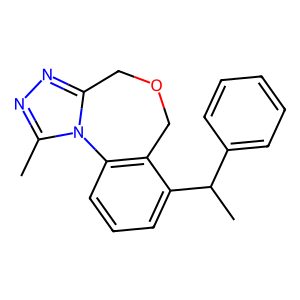

In [128]:
from py2opsin import py2opsin
from rdkit import Chem

for example in examples:
    example = '1-methyl-7-(1-phenylethyl)-4,6-dihydrobenzo[e][1,2,4]triazolo[3,4-c][1,4]oxazepine'
    print(example)
    iupac = example
    smiles_string = py2opsin(
        chemical_name = iupac,
        output_format = "SMILES",
    )
    print("SMILES:", smiles_string)
    mol = Chem.MolFromSmiles(smiles_string)
    img = Chem.Draw.MolToImage(mol)
    img.show()